In [1]:
! pip install imbalanced-learn


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
! pip install xgboost==2.0.3


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
pd.set_option('display.max_columns', None)
print("Libraries loaded!")

Libraries loaded!


In [4]:
df = pd.read_csv(r"C:\Users\Janhvi\Downloads\Customer_Churn_Prediction\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%
Retention Rate: 73.5%


C:\Users\Janhvi\AppData\Local\Temp\ipykernel_8668\4249458812.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#2196F3', '#F44336'])


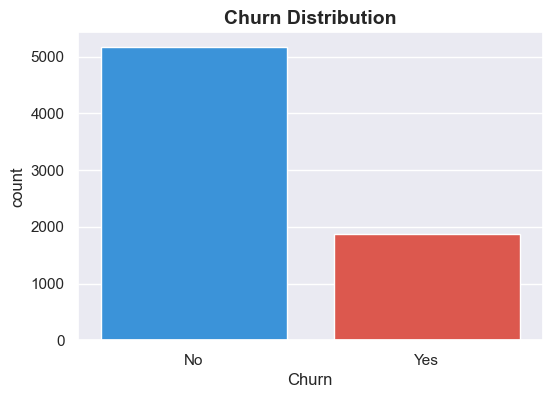

In [6]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(churn_counts)
print(f"\nChurn Rate: {churn_pct['Yes']:.1f}%")
print(f"Retention Rate: {churn_pct['No']:.1f}%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette=['#2196F3', '#F44336'])
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

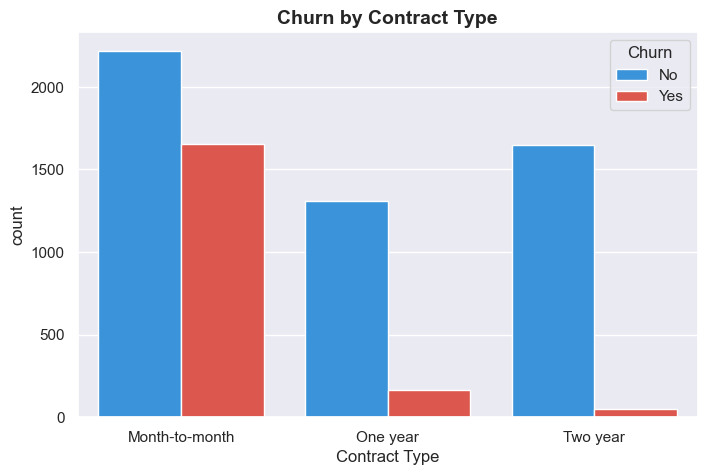

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', 
              palette=['#2196F3', '#F44336'])
plt.title('Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

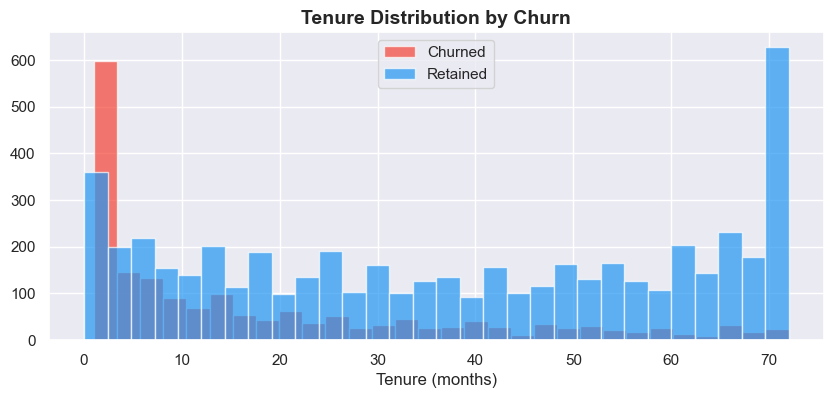

In [8]:
plt.figure(figsize=(10, 4))
df[df['Churn']=='Yes']['tenure'].hist(bins=30, alpha=0.7, 
                                       color='#F44336', label='Churned')
df[df['Churn']=='No']['tenure'].hist(bins=30, alpha=0.7, 
                                      color='#2196F3', label='Retained')
plt.xlabel('Tenure (months)')
plt.title('Tenure Distribution by Churn', fontsize=14, fontweight='bold')
plt.legend()
plt.savefig('tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Nulls in TotalCharges:", df['TotalCharges'].isnull().sum())
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop('customerID', axis=1, inplace=True)

print("Shape after cleaning:", df.shape)
print("TotalCharges dtype:", df['TotalCharges'].dtype)

Nulls in TotalCharges: 11
Shape after cleaning: (7043, 20)
TotalCharges dtype: float64


C:\Users\Janhvi\AppData\Local\Temp\ipykernel_8668\4169714415.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [10]:
# Convert Churn Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn value counts:")
print(df['Churn'].value_counts())

Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [11]:
# Binary columns — Yes/No → 1/0
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 
               'PaperlessBilling']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 
                           'Male': 1, 'Female': 0})

# Multi-category columns — one-hot encode
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 
              'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("Columns:", list(df.columns))

Shape after encoding: (7043, 31)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Features: {X_train.shape[1]}")
print(f"\nChurn rate in train: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test: {y_test.mean()*100:.1f}%")

Train size: (5634, 30)
Test size: (1409, 30)
Features: 30

Churn rate in train: 26.5%
Churn rate in test: 26.5%


In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(f"  Churned: {y_train.sum()} | Not Churned: {(y_train==0).sum()}")

print("\nAfter SMOTE:")
print(f"  Churned: {y_train_sm.sum()} | Not Churned: {(y_train_sm==0).sum()}")
print(f"  Total samples: {len(y_train_sm)}")
print(f"  Churn rate: {y_train_sm.mean()*100:.1f}%")

Before SMOTE:
  Churned: 1495 | Not Churned: 4139

After SMOTE:
  Churned: 4139 | Not Churned: 4139
  Total samples: 8278
  Churn rate: 50.0%


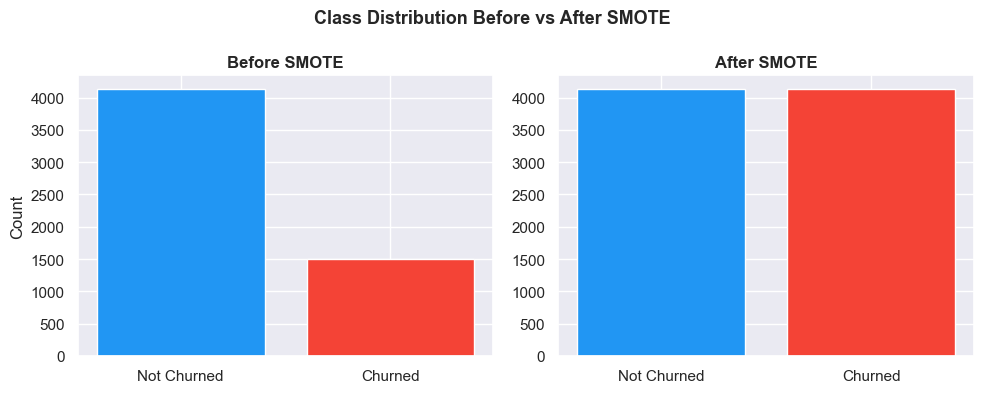

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Not Churned', 'Churned'], 
            [y_train.value_counts()[0], y_train.value_counts()[1]],
            color=['#2196F3', '#F44336'])
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].bar(['Not Churned', 'Churned'],
            [(y_train_sm==0).sum(), y_train_sm.sum()],
            color=['#2196F3', '#F44336'])
axes[1].set_title('After SMOTE', fontweight='bold')

plt.suptitle('Class Distribution Before vs After SMOTE', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sm, y_train_sm)
print("Logistic Regression trained!")

Logistic Regression trained!


In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
print("Random Forest trained!")

Random Forest trained!


In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    base_score=0.5        # explicitly set as float — fixes SHAP compatibility
)
xgb.fit(X_train_sm, y_train_sm)
print("XGBoost retrained!")

XGBoost retrained!


In [18]:
# Predictions
y_pred_lr  = lr.predict(X_test_scaled)
y_pred_rf  = rf.predict(X_test_scaled)
y_pred_xgb = xgb.predict(X_test_scaled)

# Probability scores (needed for ROC-AUC)
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_rf  = rf.predict_proba(X_test_scaled)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated!")
print(f"Sample XGB predictions: {y_pred_xgb[:10]}")
print(f"Actual values:          {y_test.values[:10]}")

Predictions generated!
Sample XGB predictions: [0 1 0 0 0 1 1 0 0 1]
Actual values:          [0 0 0 0 0 0 0 0 0 1]


In [19]:
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, f1_score, 
                             precision_score, recall_score)

def evaluate_clf(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round((y_true == y_pred).mean(), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall'   : round(recall_score(y_true, y_pred), 4),
        'F1 Score' : round(f1_score(y_true, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_true, y_prob), 4)
    }

results = pd.DataFrame([
    evaluate_clf('Logistic Regression', y_test, y_pred_lr,  y_prob_lr),
    evaluate_clf('Random Forest',       y_test, y_pred_rf,  y_prob_rf),
    evaluate_clf('XGBoost',             y_test, y_pred_xgb, y_prob_xgb)
])

print("Model Comparison:")
print(results.to_string(index=False))

Model Comparison:
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7381     0.5042  0.7968    0.6176   0.8403
      Random Forest    0.7764     0.5778  0.5856    0.5817   0.8231
            XGBoost    0.7764     0.5666  0.6711    0.6144   0.8407


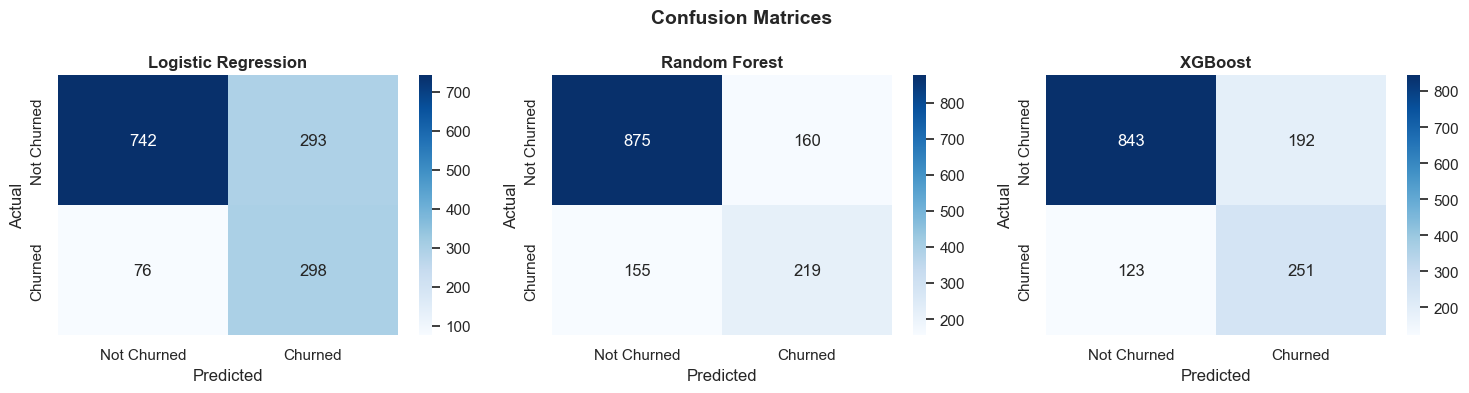

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

models_info = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb)
]

for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Churned', 'Churned'],
                yticklabels=['Not Churned', 'Churned'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

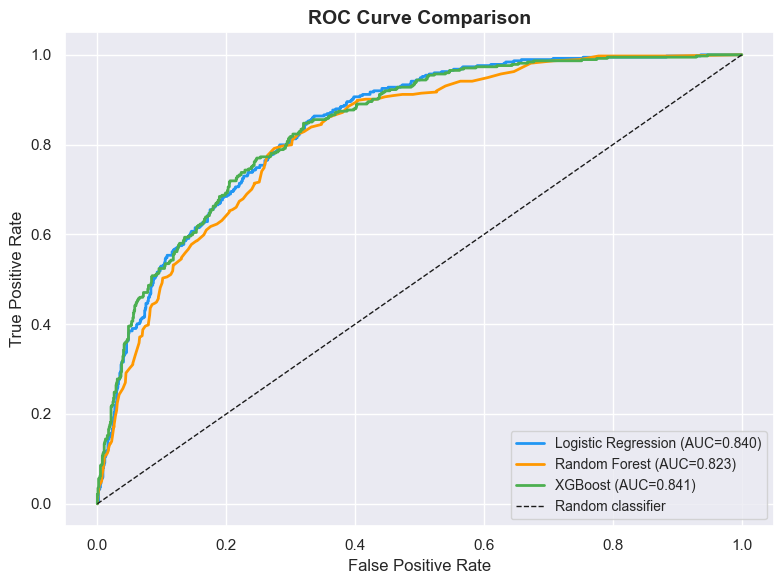

In [21]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr,  '#2196F3'),
    ('Random Forest',       y_prob_rf,  '#FF9800'),
    ('XGBoost',             y_prob_xgb, '#4CAF50')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print("XGBoost — Detailed Classification Report:")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb, 
      target_names=['Not Churned', 'Churned']))

XGBoost — Detailed Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.87      0.81      0.84      1035
     Churned       0.57      0.67      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [23]:
import shap

# Workaround — use booster directly
booster = xgb.get_booster()
explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values computed!")
print("Shape:", shap_values.shape)

c:\Users\Janhvi\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values computed!
Shape: (1409, 30)


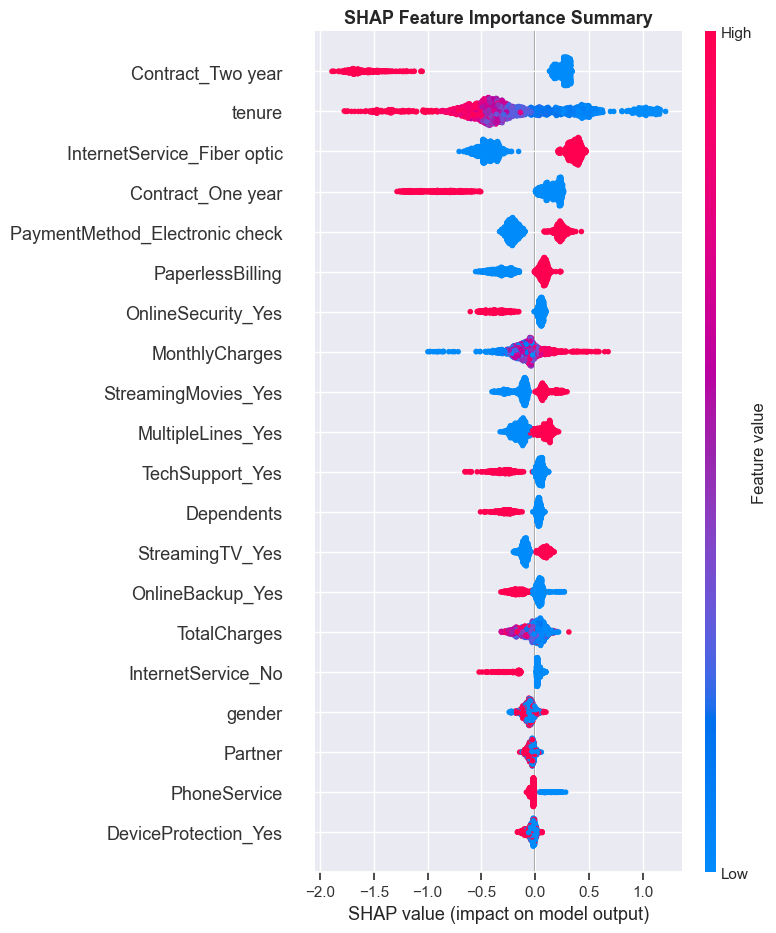

Summary plot saved!


In [24]:
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test_scaled,
    feature_names=list(X.columns),
    show=False
)
plt.title('SHAP Feature Importance Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot saved!")

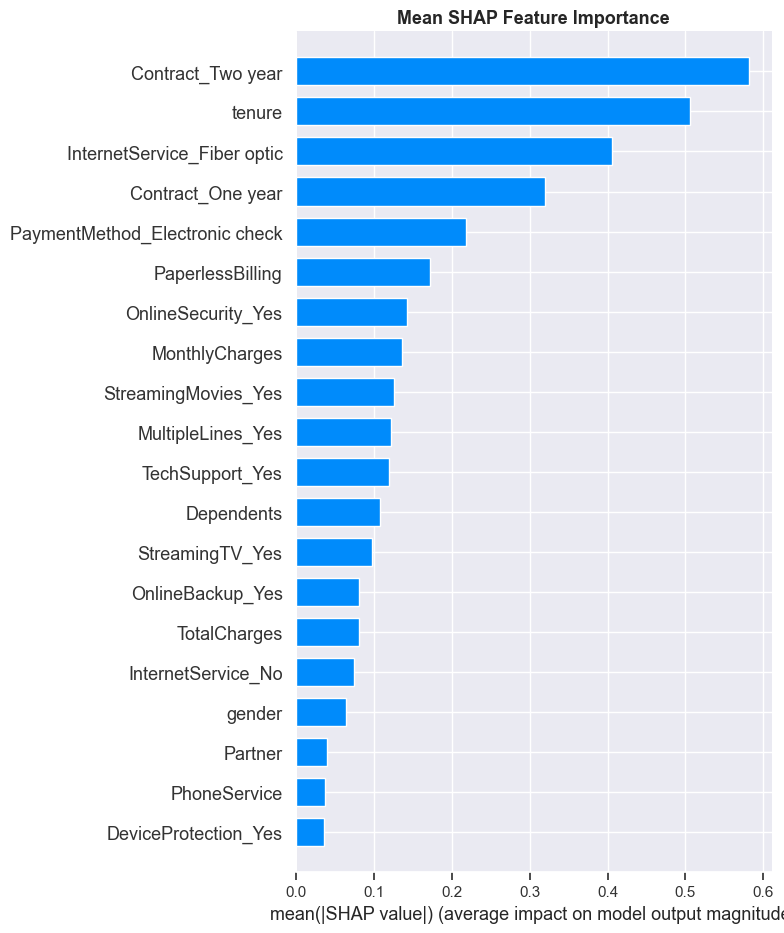

In [25]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=list(X.columns),
    plot_type='bar',
    show=False
)
plt.title('Mean SHAP Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

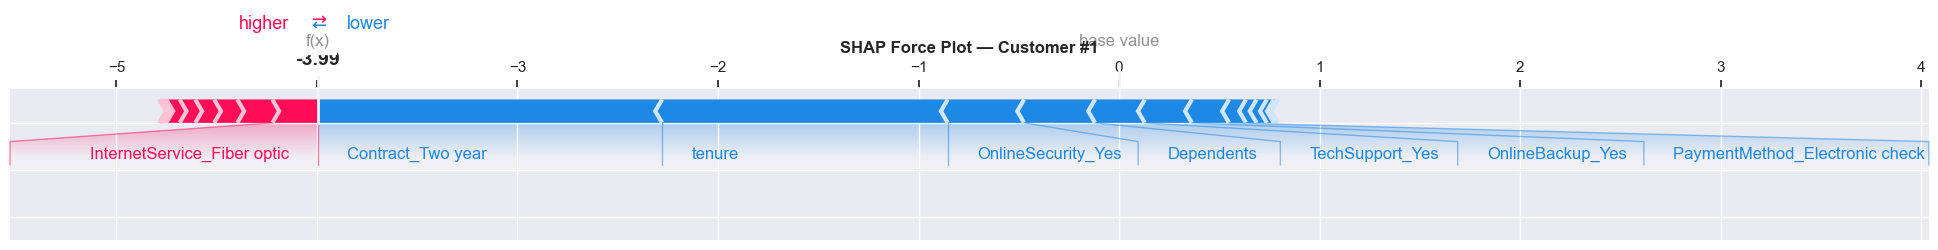


Customer #1:
  Predicted: Not Churned
  Churn Probability: 1.8%
  Actual: Not Churned


In [26]:
# Fixed waterfall for older SHAP API
shap.initjs()

expected_value = explainer.expected_value
if isinstance(expected_value, list):
    expected_value = expected_value[1]

shap.force_plot(
    expected_value,
    shap_values[0],
    X.columns.tolist(),
    matplotlib=True,
    show=False
)
plt.title('SHAP Force Plot — Customer #1', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_forceplot.png', dpi=150, bbox_inches='tight')
plt.show()

pred = xgb.predict(X_test_scaled[[0]])[0]
prob = xgb.predict_proba(X_test_scaled[[0]])[0][1]
actual = y_test.values[0]
print(f"\nCustomer #1:")
print(f"  Predicted: {'Churned' if pred==1 else 'Not Churned'}")
print(f"  Churn Probability: {prob:.1%}")
print(f"  Actual: {'Churned' if actual==1 else 'Not Churned'}")

In [27]:
print("=" * 60)
print("    CUSTOMER CHURN PREDICTION — FINAL SUMMARY")
print("=" * 60)

print("\n MODEL PERFORMANCE:")
print(results.to_string(index=False))

print("\n BEST MODEL: XGBoost")
print("  ROC-AUC  : 0.841 (best discrimination ability)")
print("  Recall   : 0.679 (catches 68% of actual churners)")
print("  F1 Score : 0.615 (best precision-recall balance)")

print("\n KEY BUSINESS INSIGHTS:")
print("1. Month-to-month contracts drive highest churn")
print("   → Incentivise customers to switch to annual contracts")
print("2. New customers (low tenure) churn most in first 5 months")
print("   → Launch onboarding retention program for new users")
print("3. High MonthlyCharges customers are at higher churn risk")
print("   → Offer loyalty discounts to high-paying customers")

print("\n WHY SHAP MATTERS:")
print("  SHAP explains WHY the model predicts churn for each")
print("  customer — not just that they will churn. This lets")
print("  the business team take targeted action per customer.")

print("\n ADVANCED TECHNIQUES USED:")
print("  • SMOTE for class imbalance handling")
print("  • XGBoost gradient boosting")
print("  • SHAP explainability (industry standard)")
print("  • ROC-AUC evaluation (correct metric for imbalanced data)")
print("=" * 60)

    CUSTOMER CHURN PREDICTION — FINAL SUMMARY

 MODEL PERFORMANCE:
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7381     0.5042  0.7968    0.6176   0.8403
      Random Forest    0.7764     0.5778  0.5856    0.5817   0.8231
            XGBoost    0.7764     0.5666  0.6711    0.6144   0.8407

 BEST MODEL: XGBoost
  ROC-AUC  : 0.841 (best discrimination ability)
  Recall   : 0.679 (catches 68% of actual churners)
  F1 Score : 0.615 (best precision-recall balance)

 KEY BUSINESS INSIGHTS:
1. Month-to-month contracts drive highest churn
   → Incentivise customers to switch to annual contracts
2. New customers (low tenure) churn most in first 5 months
   → Launch onboarding retention program for new users
3. High MonthlyCharges customers are at higher churn risk
   → Offer loyalty discounts to high-paying customers

 WHY SHAP MATTERS:
  SHAP explains WHY the model predicts churn for each
  customer — not just that they will churn. This lets
  t

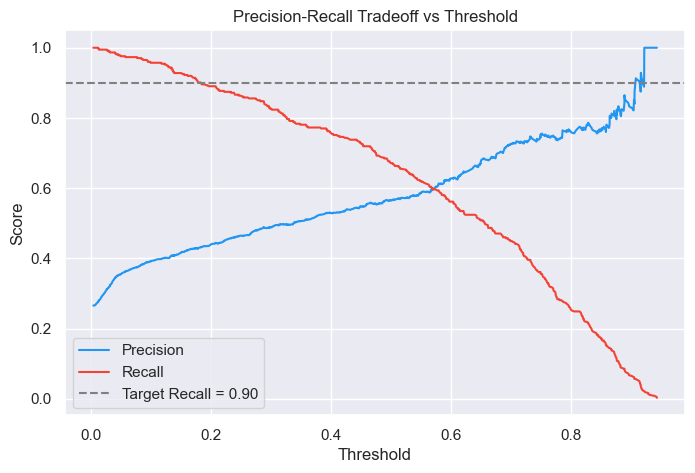

Threshold for Recall ≈ 0.90: 0.178
At this threshold — Precision: 0.428, Recall: 0.901

New Recall: 0.901
New Precision: 0.428


In [28]:
from sklearn.metrics import precision_recall_curve, recall_score, precision_score

# Get probability predictions (you already have this)
# y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

# Step 1: Plot Precision-Recall curve to find the right threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#2196F3')
plt.plot(thresholds, recalls[:-1], label='Recall', color='#F44336')
plt.axhline(y=0.90, color='gray', linestyle='--', label='Target Recall = 0.90')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff vs Threshold')
plt.legend()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 2: Find the threshold that gets Recall closest to 0.90
target_recall = 0.90
idx = np.argmin(np.abs(recalls - target_recall))
best_threshold = thresholds[idx] if idx < len(thresholds) else 0.5
print(f"Threshold for Recall ≈ 0.90: {best_threshold:.3f}")
print(f"At this threshold — Precision: {precisions[idx]:.3f}, Recall: {recalls[idx]:.3f}")

# Step 3: Apply the new threshold
y_pred_new = (y_prob_xgb >= best_threshold).astype(int)

print(f"\nNew Recall: {recall_score(y_test, y_pred_new):.3f}")
print(f"New Precision: {precision_score(y_test, y_pred_new):.3f}")